In [108]:
import os, sys, importlib,pathlib
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
import numpy as np
# my utils
from utils import axe_classification


In [3]:
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")

print(df_predicted.axe.value_counts(dropna=False),"\n")
print(df_predicted.final_axe.value_counts(dropna=False))
display(df_predicted.head())

axe
3          1107
1           684
None        617
2           252
4            46
1; 3         11
2; 3          8
1; 2          6
1; 2; 3       1
3; 1          1
3; 4          1
Name: count, dtype: int64 

final_axe
3          1324
1           811
2           269
1; 3        179
2; 3         74
4            46
1; 2; 3      18
1; 2         12
3; 4          1
Name: count, dtype: int64


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,fnege_year,axes_vec,axe1,axe2,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s,final_axe
14,hal-05354091,https://hal.science/hal-05354091v1,COMM,Les jeux vidéo FLOSS dans l’enseignement supér...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...","[-0.038245093, -0.003676773, -0.055256307, -0....","[-0.0627323, -0.012661392, -0.04260565, -0.003...",3
20,hal-05321456,https://hal.u-pec.fr/hal-05321456v1,COUV,Unlocking Organizational Identity,A Consultant’s Playbook for Inclusion Advocacy,Éric Gautier Laurent; Catherine Voynnet-Fourboul,eric-gautier; catherine-voynnet-fourboul,Institut de Recherche en Gestion; Laboratoire ...,1004418_Institut de Recherche en Gestion;10964...,Sciences de l'Homme et de la Société; Universi...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.022757635, -0.0064444183, -0.042470817, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3
33,hal-05302743,https://hal.science/hal-05302743v1,ART,Les Remote Carriers dans le combat collaborati...,None,Juliette Frédy; Cécile Godé; Philippe Lépinard,cecile-gode; philippe-lepinard,Centre d'Études et de Recherche en Gestion d'A...,420786_Université Paris-Est Créteil Val-de-Mar...,Sciences de l'Homme et de la Société; Universi...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.03761582, -0.006678919, -0.009912152, 0.01...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.074023664, 0.021094285, -0.00791859, 0.025...",3
40,hal-05295448,https://hal.science/hal-05295448v1,ART,Frugalité technologique et ludopédagogie en ma...,None,Philippe Lépinard; Prabpreet Singh,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion;17672...,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.081040576, 0.0018408684, -0.008541116, 0.0...","[-0.062362764, -0.028598065, -0.051758498, -0....","[-0.07686497, -0.0064801904, -0.03617584, -0.0...",3
42,hal-05288245,https://hal.science/hal-05288245v1,COUV,Perspectives pédagogiques ! Frugalité technolo...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.09261081, -0.01070483, -0.017841782, 0.000...","[-0.054620333, -0.028326109, -0.0541471, 0.001...","[-0.07495657, 0.0016563429, -0.018859863, 0.01...",3


## try3:

In [109]:

"""
1️⃣ 把文章当作“节点”
2️⃣ 用“关系”来定义引力（而不是直接用坐标）
3️⃣ 用 force-directed layout 来“生成坐标”


"""
import networkx as nx

df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
df=df_predicted.copy()

def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]

df['axe_list'] = df['final_axe'].apply(parse_axes)
all_axes = sorted({a for axes in df['axe_list'] for a in axes})
# display(df["axe_list"].head())

#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):# 给axe加权
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)

X = np.vstack(df['combined_emb'].dropna().values)
df_plot = df.loc[df['combined_emb'].notna()].copy()


# def main_axe(axes):
#     return axes[0] if axes else None
## 选取axe
# df_plot['main_axe'] = df_plot['axe_list'].apply(main_axe)# main/explode?

##!!!!
# 👉 同一篇文章的多个副本，在力系统中被当成多个“几乎重合的点”
# 这会导致：局部形成极强“塌缩”，spring layout 把一切压向中心
# 文章是点（node），axes 是“隐含结构”，不是点的复制器, 所以不应该按照axe进行explode！

# def explode_by_col(df, col, col_exploded):
#     df = df.copy()
#     df[col_exploded] = df[col].fillna('nan').astype(str).str.split("[,;]") # axe中有nan所以type:objet，先变成str
#     df = df.explode(col_exploded)
#     df[col_exploded] = df[col_exploded].str.strip()
#     return df[df[col_exploded].notna() & (df[col] != "")]
# df_plot_exploded=explode_by_col(df=df_plot, col="final_axe", col_exploded="final_axe_exploded")

# print(df_plot_exploded.final_axe_exploded.value_counts(dropna=False))

In [110]:
# df_plot=df_plot_exploded.copy()

#Step 1：节点 = 文章
G = nx.Graph()
for idx, row in df_plot.iterrows():
    G.add_node(
        idx,
        axes=row['axe_list'],          # 保留完整列表
        emb=row['combined_emb'],       # embedding
        n_axes=len(row['axe_list'])    # 用于可视化大小或透明度
    )

# Step 2：定义三种“力”
from sklearn.metrics.pairwise import cosine_similarity

#力 1：语义相似 → 吸引（弱）# 加强最近的10且sim大于0,85的文章之间的力？

X = np.vstack(df_plot['combined_emb'])
S = cosine_similarity(X)

K = 10 # 每个点只连最近的 K 个
sim_thresh = 0.85

for i in range(len(df_plot)):
    topk_idx = np.argpartition(-S[i], K+1)[:K+1]
    for j in topk_idx:
        if i < j and S[i,j] > sim_thresh:
            G.add_edge(i, j, weight=0.3)



# # === 3. axe 虚拟节点 (弱吸引)===
# 先假设一个axe的虚拟节点，让文章与axe节点项链，历遍所有文章时候，layout会自动拉拢同一axe下的所有文章
for idx, row in df_plot.iterrows():
    for axe in row['axe_list']:
        axe_node = f"AXE_{axe}"  
        if axe_node not in G:
            G.add_node(axe_node, type='axe') 
        G.add_edge(idx, axe_node, weight=0.1)  

        
# # 力 2：同 axe → 强吸引（关键）
# # axe 强吸引看起来“更清晰”，是因为它在“强行展示标签”，而 axe 虚拟节点展示的是“真实语义张力”。
# all_axes = sorted({a for axes in df['final_axe'] for a in axes})
# for axe in all_axes:
#     nodes = df_plot.index
#     # axe 内所有文章两两强连接
#     for i in nodes:
#         for j in nodes:
#             if i < j:
#                 G.add_edge(i, j, weight=0.7)
   
# 力 3：多 axe 文章 → 桥梁
# 多 axe 的文章自然成为桥，不需要特殊处理，它已经连着多个团。

In [ ]:
pos = nx.spring_layout(
    G,
    weight='weight',
    iterations=100,
    seed=42,
    # k=2, # k 越大，节点之间的自然间距越大，k 不是在“增加真实结构”，而是在给结构一个“能展开的空间”。
    # k controls the global repulsion scale and thus prevents excessive spatial collapse induced by multiple weak attractors.
)

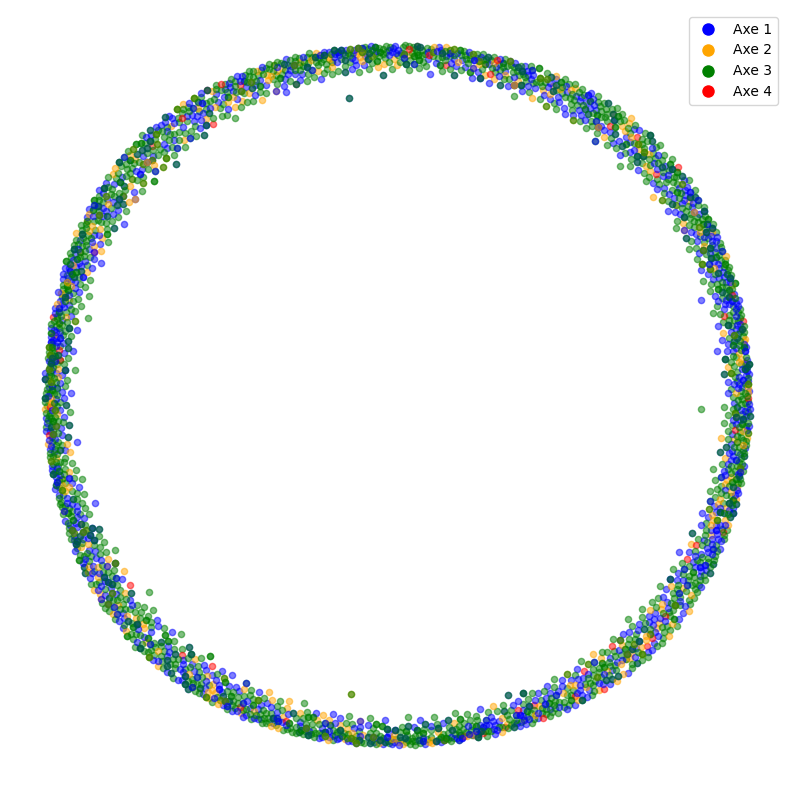

In [112]:
plt.figure(figsize=(10, 10))

# 保留原来的自动颜色映射
# 假设你已经有颜色字典或者 cmap，这里我们用 colors 映射 axe
colors = {1:'blue', 2:'orange', 3:'green', 4:'red'}
axe_label={"1":"Performances et responsabilités",
           "2":"Société de services et services à la société",
           "3":"Innovations, transformations et résistances organisationnelles et sociétales",
           "4":"Ouvrages pédagogiques"}

s_size = 20      # 点大小
alpha_val = 0.5  # 透明度

for idx, row in df_plot.iterrows():
    x, y = pos[idx]
    axes = row['axe_list']
    if len(axes) == 1:
        # 单轴文章 → 一个点
        plt.scatter(x, y, c=colors[int(axes[0])], s=s_size, alpha=alpha_val)
    else:
        # 多轴文章 → 同位置画多个颜色点
        for axe in axes:
            plt.scatter(x, y, c=colors[int(axe)], s=s_size, alpha=alpha_val)

# show legend ：只显示单轴颜色对应的 axe
from matplotlib.lines import Line2D

legend_elements = [Line2D([0],[0], marker='o', color='w', label=f"Axe {axe}",
                    markerfacecolor=color, markersize=10)
                   for axe, color in colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.axis('off')
plt.show()

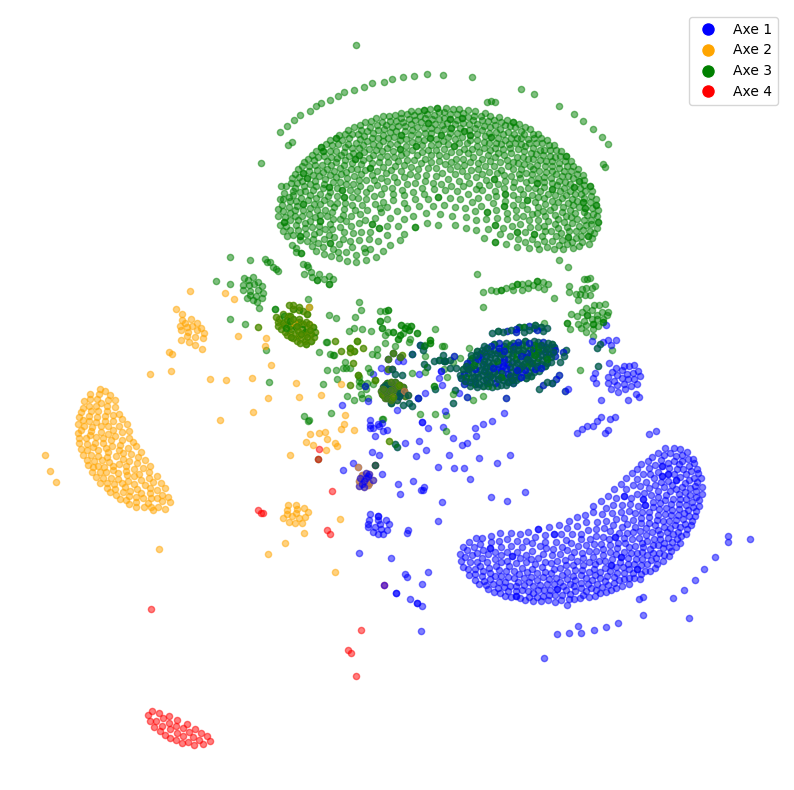

In [46]:
plt.figure(figsize=(10, 10))

# 保留原来的自动颜色映射
# 假设你已经有颜色字典或者 cmap，这里我们用 colors 映射 axe
colors = {1:'blue', 2:'orange', 3:'green', 4:'red'}
axe_label={"1":"Performances et responsabilités",
           "2":"Société de services et services à la société",
           "3":"Innovations, transformations et résistances organisationnelles et sociétales",
           "4":"Ouvrages pédagogiques"}

s_size = 20      # 点大小
alpha_val = 0.5  # 透明度

for idx, row in df_plot.iterrows():
    x, y = pos[idx]
    axes = row['axe_list']
    if len(axes) == 1:
        # 单轴文章 → 一个点
        plt.scatter(x, y, c=colors[int(axes[0])], s=s_size, alpha=alpha_val)
    else:
        # 多轴文章 → 同位置画多个颜色点
        for axe in axes:
            plt.scatter(x, y, c=colors[int(axe)], s=s_size, alpha=alpha_val)

# show legend ：只显示单轴颜色对应的 axe
from matplotlib.lines import Line2D

legend_elements = [Line2D([0],[0], marker='o', color='w', label=f"Axe {axe}",
                    markerfacecolor=color, markersize=10)
                   for axe, color in colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.axis('off')
plt.show()

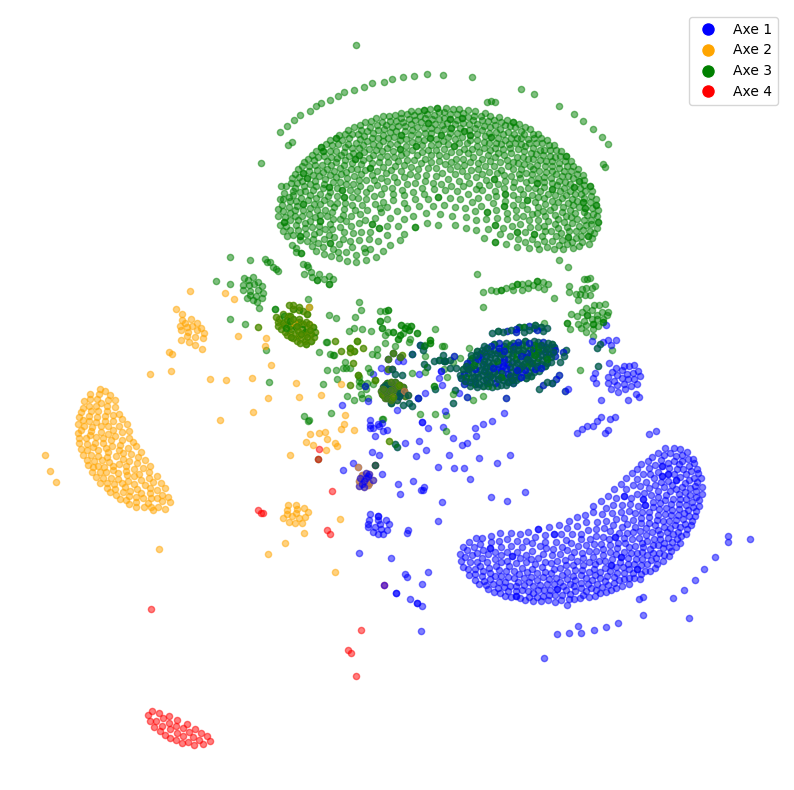

In [113]:
importlib.reload(topic_modeling)
from utils.topic_modeling import preprocess_df_for_topic_modeling, generate_force_scatterplot
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
df_plot=preprocess_df_for_topic_modeling(df_predicted)
generate_force_scatterplot(df_plot)

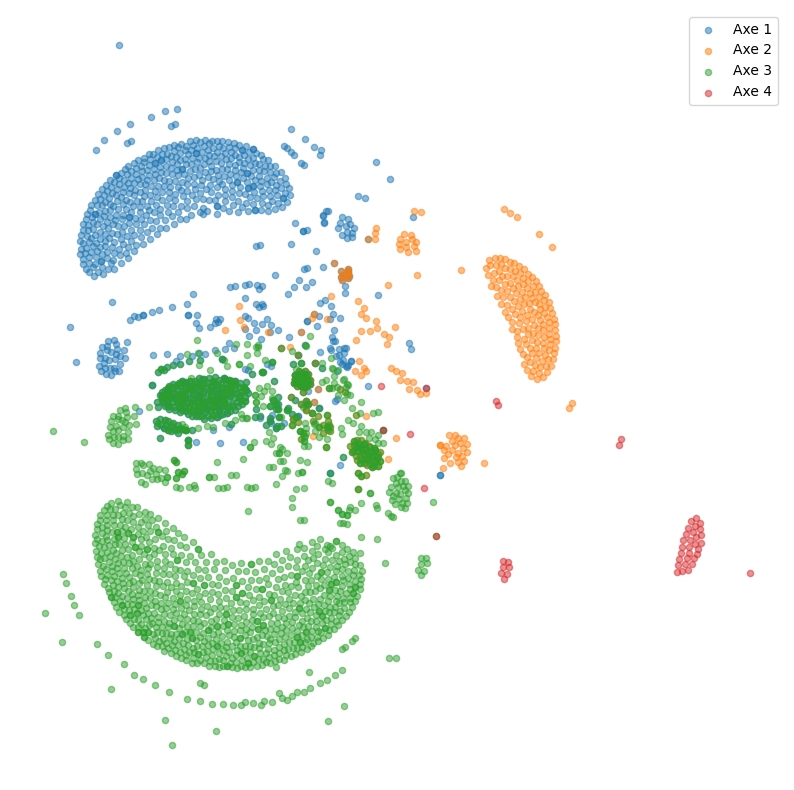

In [ ]:
#
# pos = nx.spring_layout(
#     G,
#     weight='weight',
#     iterations=100,
#     seed=42,
#     # k=2, # k 越大，节点之间的自然间距越大，k 不是在“增加真实结构”，而是在给结构一个“能展开的空间”。
#     # k controls the global repulsion scale and thus prevents excessive spatial collapse induced by multiple weak attractors.
# )

# plt.figure(figsize=(10, 10))
# for axe, g in df_plot.groupby('final_axe_exploded'):
#     idxs = g.index
#     plt.scatter(
#         [pos[i][0] for i in idxs],
#         [pos[i][1] for i in idxs],
#         s=20,
#         alpha=0.5,
#         label=f"Axe {axe}"
#     )

# plt.legend()
# plt.axis('off')
# plt.show()


## within-axe topic modeling

In [131]:
import os, sys, importlib
from utils import topic_modeling


In [133]:
importlib.reload(topic_modeling)
from utils.topic_modeling import preprocess_df_for_topic_modeling,  get_topics_per_axe
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")
df=preprocess_df_for_topic_modeling(df_predicted)
topic_model1=get_topics_per_axe(df, axe_id="1", min_topic_size=30)

2026-01-22 13:41:15,382 - BERTopic - Embedding - Transforming documents to embeddings.


[INFO] axe1 : Performances et responsabilités, 1020 texts!


Batches: 100%|██████████| 32/32 [00:14<00:00,  2.24it/s]
2026-01-22 13:41:36,004 - BERTopic - Embedding - Completed ✓
2026-01-22 13:41:36,004 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-22 13:41:37,455 - BERTopic - Dimensionality - Completed ✓
2026-01-22 13:41:37,455 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-22 13:41:37,486 - BERTopic - Cluster - Completed ✓
2026-01-22 13:41:37,489 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-22 13:41:37,565 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,575,-1_social_entreprise_corporate_performance,"[social, entreprise, corporate, performance, f...",[effects environmental performance green innov...
1,0,227,0_management_gestion_organisation_recherche,"[management, gestion, organisation, recherche,...",[pratique grh stratégie innovation apport enqu...
2,1,80,1_consommateur_brand_produit_store,"[consommateur, brand, produit, store, marque, ...",[relation mdd dire consommateur relation mdd d...
3,2,57,2_stock_market_firms_cash,"[stock, market, firms, cash, control, markets,...",[family control valoir cash holding family con...
4,3,49,3_risque_financement_crowdfunding_financier,"[risque, financement, crowdfunding, financier,...",[nouveau mode financement entreprise quel risq...


[INFO] min_topic_size : 30
1020 texts => 6 topics!
[RUNTIME]: 22.25 sec!


In [134]:
topic_model1=get_topics_per_axe(df, axe_id="2", min_topic_size=30)

2026-01-22 13:41:49,096 - BERTopic - Embedding - Transforming documents to embeddings.


[INFO] axe2 : Société de services et services à la société, 373 texts!


Batches: 100%|██████████| 12/12 [00:05<00:00,  2.23it/s]
2026-01-22 13:42:00,127 - BERTopic - Embedding - Completed ✓
2026-01-22 13:42:00,127 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-22 13:42:00,529 - BERTopic - Dimensionality - Completed ✓
2026-01-22 13:42:00,529 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-22 13:42:00,542 - BERTopic - Cluster - Completed ✓
2026-01-22 13:42:00,544 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-22 13:42:00,580 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,127,-1_service_patient_client_customer,"[service, patient, client, customer, relation,...",[représentation patient âgé pratique gestion s...
1,0,144,0_marketing_client_service_consommateur,"[marketing, client, service, consommateur, par...",[client exécutant assistant marketing opératio...
2,1,102,1_travail_work_social_management,"[travail, work, social, management, profession...",[could eco cities enable new ways living toget...


[INFO] min_topic_size : 30
373 texts => 3 topics!
[RUNTIME]: 11.52 sec!


In [139]:
topic_model3=get_topics_per_axe(df, axe_id="3", min_topic_size=20)

2026-01-22 13:43:58,883 - BERTopic - Embedding - Transforming documents to embeddings.


[INFO] axe3 : Innovations, transformations et résistances organisationnelles et sociétales, 1596 texts!


Batches: 100%|██████████| 50/50 [00:21<00:00,  2.36it/s]
2026-01-22 13:44:24,253 - BERTopic - Embedding - Completed ✓
2026-01-22 13:44:24,253 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-22 13:44:26,686 - BERTopic - Dimensionality - Completed ✓
2026-01-22 13:44:26,686 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-22 13:44:26,731 - BERTopic - Cluster - Completed ✓
2026-01-22 13:44:26,734 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-22 13:44:26,831 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,80,-1_stratégique_stratégie_pratique_foucault,"[stratégique, stratégie, pratique, foucault, p...",[approche discursif stratégie approche discurs...
1,0,1459,0_management_recherche_innovation_social,"[management, recherche, innovation, social, re...",[organiser alternative pratique gestion transi...
2,1,57,1_parfumerie_siècle_xixe_perfumery,"[parfumerie, siècle, xixe, perfumery, parfum, ...",[parfumerie parisien xixe siècle fabrique indu...


[INFO] min_topic_size : 20
1596 texts => 3 topics!
[RUNTIME]: 28.00 sec!


In [154]:
importlib.reload(topic_modeling)
from utils.topic_modeling import preprocess_df_for_topic_modeling,  get_topics_per_axe
topic_model4, topic_info4=get_topics_per_axe(df, axe_id="4", min_topic_size=5)

2026-01-22 13:54:06,341 - BERTopic - Embedding - Transforming documents to embeddings.


[INFO] axe4 : Ouvrages pédagogiques, 47 texts!


Batches: 100%|██████████| 2/2 [00:00<00:00,  2.82it/s]
2026-01-22 13:54:11,506 - BERTopic - Embedding - Completed ✓
2026-01-22 13:54:11,509 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-22 13:54:11,560 - BERTopic - Dimensionality - Completed ✓
2026-01-22 13:54:11,562 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-22 13:54:11,565 - BERTopic - Cluster - Completed ✓
2026-01-22 13:54:11,565 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-22 13:54:11,575 - BERTopic - Representation - Completed ✓


[INFO] min_topic_size : 5
47 texts => 1 topics!
[RUNTIME]: 5.24 sec!


,Topic,Count,Name,Representation,Representative_Docs
0,-1,47,-1_recherche_management_cas_entreprise,"[recherche, management, cas, entreprise, actio...",[méthode qualitatif recherche management voie ...


In [ ]:

topic_model=topic_model4
topic_info=topic_info4

axe_id='4'
df_axe = df[df['axe_list'].apply(lambda x: axe_id in x)].copy()


rep_docs=topic_info['Representative_Docs']
print(len(rep_docs))

df_axe_rep=df_axe[df_axe['clean_text'].isin(rep_docs)]
topic_info['Representative_titles']=df_axe_rep['title_s'].to_list()
display(topic_info)
# topic_info=topic_info.merge(df_axe, left_on="Representative_Docs", right_on='clean_text', how='left')
# display(topic_info)

# rep_docs=topic_info['Representative_Docs'][0]
# print(len(topic_info['Representative_Docs'][0]))






# # print(type(rep_doc))

# df_axe = df[df['axe_list'].apply(lambda x: axe_id in x)].copy()

# df_axe_rep=df_axe[df_axe['clean_text'].isin(rep_docs)]
# display(df_axe_rep)

ValueError: Length of values (0) does not match length of index (1)

In [ ]:
df=df_predicted.copy()

# axe
def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]
df['axe_list'] = df['final_axe'].apply(parse_axes)


# text
def build_text(row):
    parts = []
    if pd.notna(row['title_s']):
        parts.append(row['title_s'])
        parts.append(row['title_s'])  # title 加权（重复一次）
    if pd.notna(row['keyword_s']):
        parts.append(row['keyword_s'])
    if pd.notna(row['abstract_s']):
        parts.append(row['abstract_s'])
    return " ".join(parts)

df['text'] = df.apply(build_text, axis=1)

from utils.preprocess import preprocess_text
df['clean_text']=df["text"].apply(preprocess_text)


# emb
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):# 给axe加权
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)

X = np.vstack(df['combined_emb'].dropna().values)
df = df.loc[df['combined_emb'].notna()].copy()

print(len(df))
display(df.head())

2734


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s,final_axe,axe_list,text,clean_text,combined_emb
14,hal-05354091,https://hal.science/hal-05354091v1,COMM,Les jeux vidéo FLOSS dans l’enseignement supér...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,1,0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...","[-0.038245093, -0.003676773, -0.055256307, -0....","[-0.0627323, -0.012661392, -0.04260565, -0.003...",3,[3],Les jeux vidéo FLOSS dans l’enseignement supér...,jeu vidéo floss enseignement supérieur jeu vid...,"[-0.05788051175910073, -0.01310115000484763, -..."
20,hal-05321456,https://hal.u-pec.fr/hal-05321456v1,COUV,Unlocking Organizational Identity,A Consultant’s Playbook for Inclusion Advocacy,Éric Gautier Laurent; Catherine Voynnet-Fourboul,eric-gautier; catherine-voynnet-fourboul,Institut de Recherche en Gestion; Laboratoire ...,1004418_Institut de Recherche en Gestion;10964...,Sciences de l'Homme et de la Société; Universi...,...,1,0,"[-0.022757635, -0.0064444183, -0.042470817, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3,[3],Unlocking Organizational Identity Unlocking Or...,unlocking organizational identity unlocking or...,"[-0.006150712032575865, -0.0017417346857286787..."
33,hal-05302743,https://hal.science/hal-05302743v1,ART,Les Remote Carriers dans le combat collaborati...,None,Juliette Frédy; Cécile Godé; Philippe Lépinard,cecile-gode; philippe-lepinard,Centre d'Études et de Recherche en Gestion d'A...,420786_Université Paris-Est Créteil Val-de-Mar...,Sciences de l'Homme et de la Société; Universi...,...,1,0,"[-0.03761582, -0.006678919, -0.009912152, 0.01...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.074023664, 0.021094285, -0.00791859, 0.025...",3,[3],Les Remote Carriers dans le combat collaborati...,remote carrier combat collaboratif articuler c...,"[-0.04017603155728933, 0.00674662394197406, -0..."
40,hal-05295448,https://hal.science/hal-05295448v1,ART,Frugalité technologique et ludopédagogie en ma...,None,Philippe Lépinard; Prabpreet Singh,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion;17672...,Sciences de l'Homme et de la Société; Biblioth...,...,1,0,"[-0.081040576, 0.0018408684, -0.008541116, 0.0...","[-0.062362764, -0.028598065, -0.051758498, -0....","[-0.07686497, -0.0064801904, -0.03617584, -0.0...",3,[3],Frugalité technologique et ludopédagogie en ma...,frugalité technologique ludopédagogie manageme...,"[-0.0732900951359723, -0.011404620200345243, -..."
42,hal-05288245,https://hal.science/hal-05288245v1,COUV,Perspectives pédagogiques ! Frugalité technolo...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,1,0,"[-0.09261081, -0.01070483, -0.017841782, 0.000...","[-0.054620333, -0.028326109, -0.0541471, 0.001...","[-0.07495657, 0.0016563429, -0.018859863, 0.01...",3,[3],Perspectives pédagogiques ! Frugalité technolo...,perspective pédagogique frugalité technologiqu...,"[-0.07313245232846285, -0.011408553197602363, ..."


In [118]:
axe_id = '1'
df_axe = df[df['axe_list'].apply(lambda x: axe_id in x)].copy()
texts = df_axe['clean_text'].tolist()
embemddings = np.vstack(df_axe['combined_emb'])
print(len(texts))

axe_label={"1":"Performances et responsabilités",
           "2":"Société de services et services à la société",
           "3":"Innovations, transformations et résistances organisationnelles et sociétales",
           "4":"Ouvrages pédagogiques"}
print(axe_label.get(axe_id))

1020
Performances et responsabilités


In [ ]:
# axes=["1","2","3","4"]
# for axe_id in axes:
#     df_axe_= df_plot[df_plot['axe_list'].apply(lambda x: axe_id in x)].copy()
#     # texts = df_axe['clean_text'].tolist()
#     # embemddings = np.vstack(df_axe['combined_emb'])
#     min_topic_size = max(5, int(0.02 * len(df_axe_)))
#     print('len texts:',len(df_axe_),"min_topic_size:",min_topic_size)

len texts: 1020 min_topic_size: 20
len texts: 373 min_topic_size: 7
len texts: 1596 min_topic_size: 31
len texts: 47 min_topic_size: 5


In [119]:
axe_id = '1'
df_axe = df[df['axe_list'].apply(lambda x: axe_id in x)].copy()
texts = df_axe['clean_text'].tolist()
print(len(texts))

1020


In [128]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP


min_topic_size=30


# min_topic_size = max(10, int(0.02 * len(texts)))
# print("min_topic_size:",min_topic_size)

# 默认设置：
# | 步骤  | 模型      |
# | --- | --------   |
# | 降维  | UMAP     |
# | 聚类  | HDBSCAN  |
# | 关键词 | c-TF-IDF |

# custom_stopwords = ["de", "la", "et", "des", "le", "les", "the", "of", "and", "to", "in", "en", "une", "une"]
# vectorizer_model = CountVectorizer(
#     stop_words=custom_stopwords,
#     ngram_range=(1,2)  # 抽取 unigram + bigram
# )

# topic_model = BERTopic(
#     # language="multilingual",  # 如果是法文 / 多语言
#     vectorizer_model=vectorizer_model,
#     language=None, 
#     # min_topic_size=20, # 保证每个 topic 至少 n 篇文章XXX
#     calculate_probabilities=True,#probs[i, k] = 文档 i 属于 topic k 的概率
#     verbose=True # 
# )
#是否需要更具备一个axe调参？没办法统一处理

umap_model = UMAP(
    n_neighbors=5,    # 控制局部邻域大小; 越大topic越宽泛
    n_components=5,    # 降维输出维度，一般 topic 建模用 5~50，默认 2 可视化
    min_dist=0.0,      # 控制低维 embedding 中的最小点间距离
    metric='cosine',   # 距离度量，文本通常用 cosine 更合理
    random_state=42    # 固定随机种子，保证可复现
)

topic_model = BERTopic(
    language="multilingual",  # 如果是法文 / 多语言
    calculate_probabilities=True,#probs[i, k] = 文档 i 属于 topic k 的概率
    min_topic_size=min_topic_size,
    verbose=True, 
    low_memory=False,
    umap_model=UMAP(random_state=42)
    # umap_model= umap_model #决定降维
)
topics, probs = topic_model.fit_transform(texts)

# nr_topics="auto", 调整topic的数量
# topics, probs = topic_model.fit_transform(texts, embeddings)

2026-01-22 13:33:43,706 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 32/32 [00:14<00:00,  2.24it/s]
2026-01-22 13:34:03,706 - BERTopic - Embedding - Completed ✓
2026-01-22 13:34:03,709 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-22 13:34:05,070 - BERTopic - Dimensionality - Completed ✓
2026-01-22 13:34:05,071 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-22 13:34:05,116 - BERTopic - Cluster - Completed ✓
2026-01-22 13:34:05,119 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-22 13:34:05,198 - BERTopic - Representation - Completed ✓


In [129]:
print(f"{len(set(topics))} topics dans {len(df_axe)} textes")
topic_info = topic_model.get_topic_info()
display(topic_info)

6 topics dans 1020 textes


,Topic,Count,Name,Representation,Representative_Docs
0,-1,575,-1_social_entreprise_corporate_performance,"[social, entreprise, corporate, performance, f...",[effects environmental performance green innov...
1,0,227,0_management_gestion_organisation_recherche,"[management, gestion, organisation, recherche,...",[pratique grh stratégie innovation apport enqu...
2,1,80,1_consommateur_brand_produit_store,"[consommateur, brand, produit, store, marque, ...",[relation mdd dire consommateur relation mdd d...
3,2,57,2_stock_market_firms_cash,"[stock, market, firms, cash, control, markets,...",[family control valoir cash holding family con...
4,3,49,3_risque_financement_crowdfunding_financier,"[risque, financement, crowdfunding, financier,...",[nouveau mode financement entreprise quel risq...
5,4,32,4_durable_sustainable_développement_development,"[durable, sustainable, développement, developm...",[repenser responsabilité sociétal marque ère s...


In [127]:
print(f"{len(set(topics))} topics dans {len(df_axe)} textes")
topic_info = topic_model.get_topic_info()
display(topic_info)
##对整体进行topic modeling的效果不好

5 topics dans 1020 textes


,Topic,Count,Name,Representation,Representative_Docs
0,-1,144,-1_public_contrôle_alternative_corporate,"[public, contrôle, alternative, corporate, man...",[pilotage reddition quoi servir reporting extr...
1,0,630,0_social_management_entreprise_recherche,"[social, management, entreprise, recherche, ge...",[collectif interest cooperative company scic s...
2,1,94,1_firms_ownership_disclosure_information,"[firms, ownership, disclosure, information, fr...",[ownership structure voluntary r disclosure ma...
3,2,83,2_capital_venture_risque_corporate,"[capital, venture, risque, corporate, financem...",[corporate venture capital strategy knowledge ...
4,3,69,3_stock_market_performance_markets,"[stock, market, performance, markets, financia...",[scrutinizing portfolio strategies asset prici...


In [124]:
print(f"{len(set(topics))} topics sous axe{axe_id} : {axe_label.get(axe_id)}")
topic_info = topic_model.get_topic_info()

display(topic_info)

df_axe["topic"]=topics
display(df_axe.head())
for t in set(topics):
    df_axe_topic=df_axe[df_axe["topic"]==t]
    print(f"topic{t} : {len(df_axe_topic)}")
    print('\n '.join(df_axe_topic["title_s"].to_list()))
    break

3 topics sous axe1 : Performances et responsabilités


,Topic,Count,Name,Representation,Representative_Docs
0,-1,170,-1_management_impact_performance_venture,"[management, impact, performance, venture, cap...",[adaptation système contrôle temps crise perce...
1,0,603,0_social_entreprise_management_recherche,"[social, entreprise, management, recherche, ge...",[entreprise responsabilité social question sav...
2,1,247,1_market_corporate_firms_stock,"[market, corporate, firms, stock, french, fina...",[ownership structure voluntary r disclosure ma...


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,axe4,emb_title_s,emb_keyword_s,emb_abstract_s,final_axe,axe_list,text,clean_text,combined_emb,topic
51,hal-05270413,https://hal.science/hal-05270413v1,COMM,Entre logique et attitudes : une approche sémi...,None,Alvin Panjeta,alvin-panjeta,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Universi...,...,0,"[-0.059777837, -0.013543744, -0.02277534, 0.01...","[-0.028406061, 0.011631566, -0.0468394, -0.027...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1; 3,"[1, 3]",Entre logique et attitudes : une approche sémi...,logique attitude approche sémiotique outil ges...,"[-0.025368948844639028, 0.00011192856205476268...",0
58,hal-05243035,https://hal.science/hal-05243035v1,COMM,Le consumérisme digital au service des transit...,None,Laurence Beierlein,None,Institut de Recherche en Gestion,57129_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Institut...,...,0,"[-0.07361743, -0.019642955, -0.010537421, -0.0...","[-0.07811292, 0.019240255, 0.004032814, 0.0007...","[-0.104878984, -0.004122043, -0.0010956787, 0....",1,[1],Le consumérisme digital au service des transit...,consumérisme digital service transition socio ...,"[-0.08774903034036223, -0.0007399226463324316,...",0
68,hal-05223781,https://hal.science/hal-05223781v1,ART,Women directors on traditionally male-dominate...,None,Laura Padilla Angulo; Faten Ben Slimane,faten-ben-slimane,Institut de Recherche en Gestion,506221_Universidad Loyola Andalucía = Loyola U...,Sciences de l'Homme et de la Société; Institut...,...,0,"[-0.072754726, -0.034324262, -0.051252168, -0....","[-0.075722836, -0.0138679985, -0.032692563, -0...","[-0.07057659, -0.009411376, -0.031515896, 0.00...",1,[1],Women directors on traditionally male-dominate...,women directors traditionally mal dominated st...,"[-0.07283432942789954, -0.017589979578514357, ...",-1
74,hal-05214171,https://hal.u-pec.fr/hal-05214171v1,ART,De la RSE à la Responsabilité Territoriale des...,None,Éric Gautier Laurent,eric-gautier,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Institut...,...,0,"[-0.041773275, -0.0025241068, 0.000555861, -0....","[-0.02150615, 0.01227378, 0.01302773, -0.00662...","[-0.026997523, 0.028717287, 0.003255852, -0.03...",1,[1],De la RSE à la Responsabilité Territoriale des...,rse responsabilité territorial entreprise expl...,"[-0.02920998345959831, 0.014940637742748132, 0...",0
94,hal-05111200,https://hal.science/hal-05111200v1,COUV,Critiques anciennes et renouvelées de la produ...,None,Salomon Bernier-Khedache; Stéphane Deschaintre,salomon-bernier-khedache; stephane-deschaintre,Institut de Recherche en Gestion; Val de Loire...,57129_Institut de Recherche en Gestion;190457_...,Sciences de l'Homme et de la Société; Universi...,...,0,"[-0.024860166, 0.02784227, -0.041644022, 0.027...","[0.0086414395, 0.0009148625, -0.045222178, 0.0...","[-0.034569986, 0.051778894, -0.023232486, 0.00...",1,[1],Critiques anciennes et renouvelées de la produ...,critique ancien renouveler productivité mainte...,"[-0.017931194019478718, 0.028813093535702772, ...",0


topic0 : 603
Entre logique et attitudes : une approche sémiotique des outils de gestion
 Le consumérisme digital au service des transitions socio-environnementales ? Le cas d’une start-up spécialisée dans l’évaluation sociétale des produits alimentaires
 De la RSE à la Responsabilité Territoriale des Entreprises : une exploration anthropologique en Polynésie Française
 Critiques anciennes et renouvelées de la productivité : et maintenant, on fait quoi ?
 Ces agent·es qui ne font (pas) que passer.
 From sustainability to forest-ability: a semio-pragmatist approach to the living beings
 Signs of forest-ability: a semio-pragmatist account of creative approaches to sustainability
 Détourner la lutte contre les violences sexuelles, un stratagème efficace ? Le cas des luttes de pouvoir au sein du mouvement Emmaüs (2023-2024)
 La culture : une opportunité de différenciation touristique
 (In)compatibilités des exigences RH de l'accréditation américaine AACSB au contexte universitaire français

In [91]:
for topic_id in set(topics):
    print(topic_id, len(topic_model.get_topic(topic_id)))
    
    print(topic_model.get_topic(topic_id))


0 10
[('management', np.float64(0.039586774572878215)), ('gestion', np.float64(0.03123174282629119)), ('organisation', np.float64(0.023560737998982204)), ('recherche', np.float64(0.020831933529765267)), ('csr', np.float64(0.020414561691302388)), ('travail', np.float64(0.020312639166331685)), ('social', np.float64(0.01975398601129431)), ('entreprise', np.float64(0.018687480549568477)), ('action', np.float64(0.017984809415587576)), ('public', np.float64(0.01686044887258398))]
1 10
[('consommateur', np.float64(0.06323541273820119)), ('brand', np.float64(0.04285758911175777)), ('produit', np.float64(0.040906739439151706)), ('store', np.float64(0.03738575895143907)), ('marque', np.float64(0.037078298210605806)), ('communication', np.float64(0.030885790250606737)), ('recherche', np.float64(0.029589133665308343)), ('comportement', np.float64(0.027668403752646058)), ('marketing', np.float64(0.02727680474387933)), ('distributeur', np.float64(0.026804616081194214))]
2 10
[('stock', np.float64(0.

## Multi-topic word cloud

In [ ]:
words = dict(topic_model.get_topic(topic_id))
print(words)

# 获取 topic 的词权重
topic_words = topic_model.get_topic(topic_id)  # list of (word, weight)
count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]  # 该 topic 文档数
# 定义阈值，过滤掉太小的词
threshold = 0.01
# 生成词云用的字典，weight * count
words = {word: weight * count for word, weight in topic_words if weight * count >= threshold}
print(words)

{'durable': np.float64(0.11129981434720605), 'sustainable': np.float64(0.10428736354566724), 'développement': np.float64(0.09981534323587296), 'development': np.float64(0.08955452268065421), 'social': np.float64(0.06350678132850643), 'responsabilité': np.float64(0.05584034955428395), 'entreprise': np.float64(0.05491008186001498), 'distributeur': np.float64(0.04512626840258853), 'stratégie': np.float64(0.04082626208979469), 'indépendant': np.float64(0.03509824114861309)}
{'durable': np.float64(3.5615940591105937), 'sustainable': np.float64(3.3371956334613517), 'développement': np.float64(3.1940909835479347), 'development': np.float64(2.8657447257809348), 'social': np.float64(2.0322170025122057), 'responsabilité': np.float64(1.7868911857370864), 'entreprise': np.float64(1.7571226195204794), 'distributeur': np.float64(1.444040588882833), 'stratégie': np.float64(1.30644038687343), 'indépendant': np.float64(1.1231437167556189)}


[-1, 0, 1, 2, 3, 4]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_14088\298637570.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



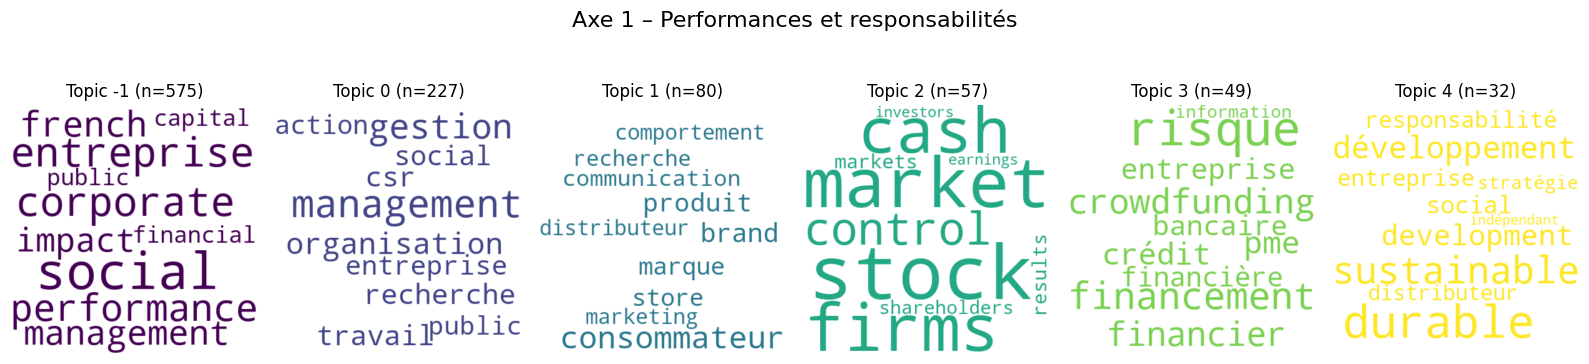

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

topic_ids = topic_info['Topic'].tolist()
print(topic_ids)
cmap = cm.get_cmap("viridis", len(topic_ids))  # len(topic_ids) 个颜色
topic_colors = {topic_id: cmap(i) for i, topic_id in enumerate(topic_ids)}

from wordcloud import WordCloud
fig, axes = plt.subplots(1, len(topic_ids), figsize=(16,4))
for ax, topic_id in zip(axes, topic_ids):
    words = dict(topic_model.get_topic(topic_id))#{word:weight}    
    count = topic_info.loc[topic_info.Topic==topic_id, 'Count'].values[0]# showed in title
    
    
    # #words2
    # topic_words = topic_model.get_topic(topic_id)  # list of (word, weight)
    # count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]  # 该 topic 文档数
    # threshold = 0.01
    # words = {word: weight * count for word, weight in topic_words if weight * count >= threshold}

    # WordCloud 支持 colormap
    wc = WordCloud(
        background_color="white",
        colormap=cm.colors.ListedColormap([topic_colors[topic_id]]),  # 每个 topic 单色
        width=400,
        height=400
    ).generate_from_frequencies(words)

    ax.imshow(wc, interpolation='bilinear')
    # ax.set_title(f"Topic {topic_id}", fontsize=12)
    ax.set_title(f"Topic {topic_id} (n={count})", fontsize=12)

    ax.axis("off")

fig.suptitle(f"Axe {axe_id} – {axe_label.get(axe_id)}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

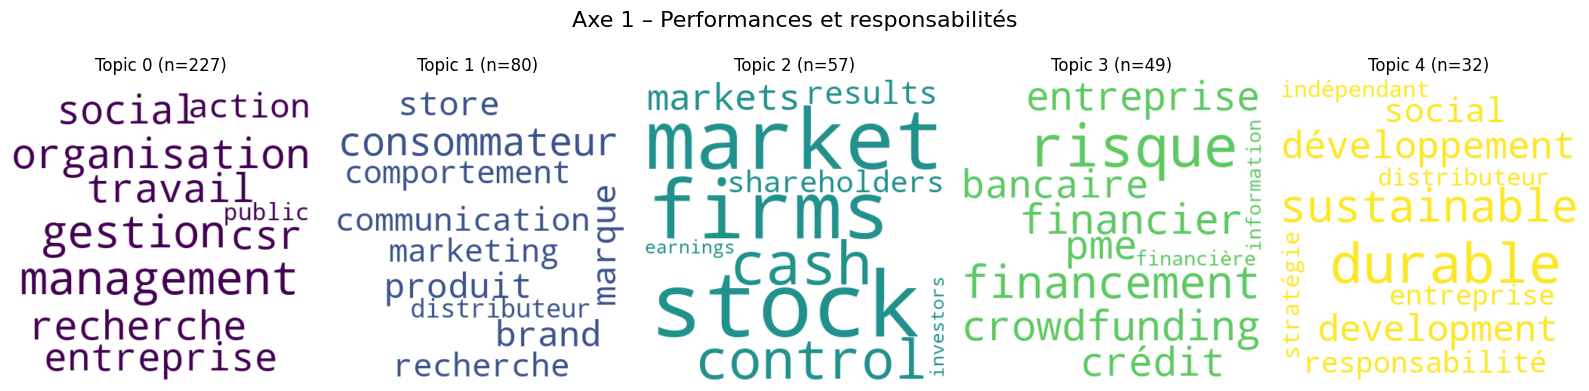

In [ ]:


# from wordcloud import WordCloud
# fig, axes = plt.subplots(1, len(topic_ids), figsize=(16,4))
# for ax, topic_id in zip(axes, topic_ids):
#     # words1
#     # words = dict(topic_model.get_topic(topic_id))#{word:weight}    
#     # count = topic_info.loc[topic_info.Topic==topic_id, 'Count'].values[0]# showed in title
    
    
#     #words2
#     topic_words = topic_model.get_topic(topic_id)  # list of (word, weight)
#     count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]  # 该 topic 文档数
#     threshold = 0.01
#     words = {word: weight * count for word, weight in topic_words if weight * count >= threshold}
#     words_scaled = {w: np.sqrt(v) for w, v in words.items()}

#     # WordCloud 支持 colormap
#     wc = WordCloud(
#         background_color="white",
#         colormap=cm.colors.ListedColormap([topic_colors[topic_id]]),  # 每个 topic 单色
#         width=400,
#         height=400
#     ).generate_from_frequencies(words_scaled)

#     ax.imshow(wc, interpolation='bilinear')
#     # ax.set_title(f"Topic {topic_id}", fontsize=12)
#     ax.set_title(f"Topic {topic_id} (n={count})", fontsize=12)

#     ax.axis("off")

# fig.suptitle(f"Axe {axe_id} – {axe_label.get(axe_id)}", fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

In [54]:
import matplotlib.pyplot as plt
import numpy as np

## Step 1：准备 topic → 颜色
topic_ids = topic_info[topic_info.Topic != -1]['Topic'].tolist()

colors = plt.cm.tab10(np.linspace(0, 1, len(topic_ids)))
topic_color = dict(zip(topic_ids, colors))


## Step 2：收集所有词、大小、颜色
words = []
sizes = []
cols = []
xs = []
ys = []

x_offset = 0

for topic_id in topic_ids:
    topic_words = topic_model.get_topic(topic_id)
    count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]

    for word, weight in topic_words:
        words.append(word)
        sizes.append(count * weight )  # scaling
        cols.append(topic_color[topic_id])
        xs.append(x_offset + np.random.normal(scale=0.3))
        ys.append(np.random.normal(scale=0.3))

    x_offset += 5  # 控制不同 topic 之间的距离
    
    
##check
print(min(sizes), max(sizes))
print(min(xs), max(xs), min(ys), max(ys))


1.1231437167556189 8.986197828043355
-0.4438792273865461 20.526670664629524 -0.7427215121205719 0.7200492079181144


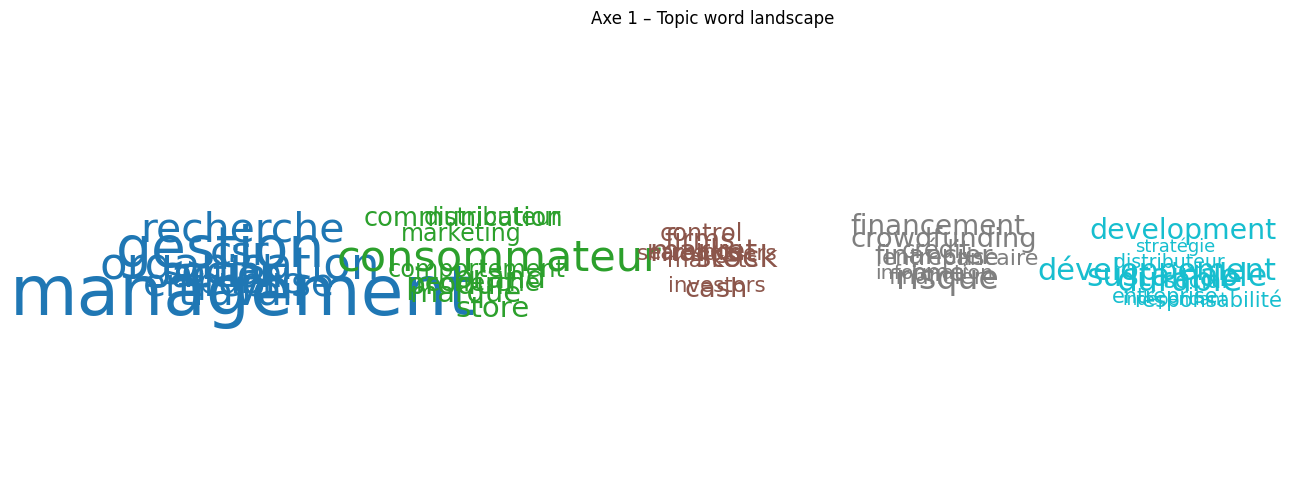

In [55]:
plt.close('all')

# 安全缩放
sizes_scaled = np.interp(
    sizes,
    (min(sizes), max(sizes)),
    (12, 50)
)

plt.figure(figsize=(14,6))

for x, y, word, size, col in zip(xs, ys, words, sizes_scaled, cols):
    plt.text(
        x, y, word,
        fontsize=size,
        color=col,
        ha='center',
        va='center'
    )

plt.xlim(min(xs)-1, max(xs)+1)
plt.ylim(min(ys)-3, max(ys)+3)

plt.axis('off')
plt.title(f"Axe {axe_id} – Topic word landscape")
plt.show()


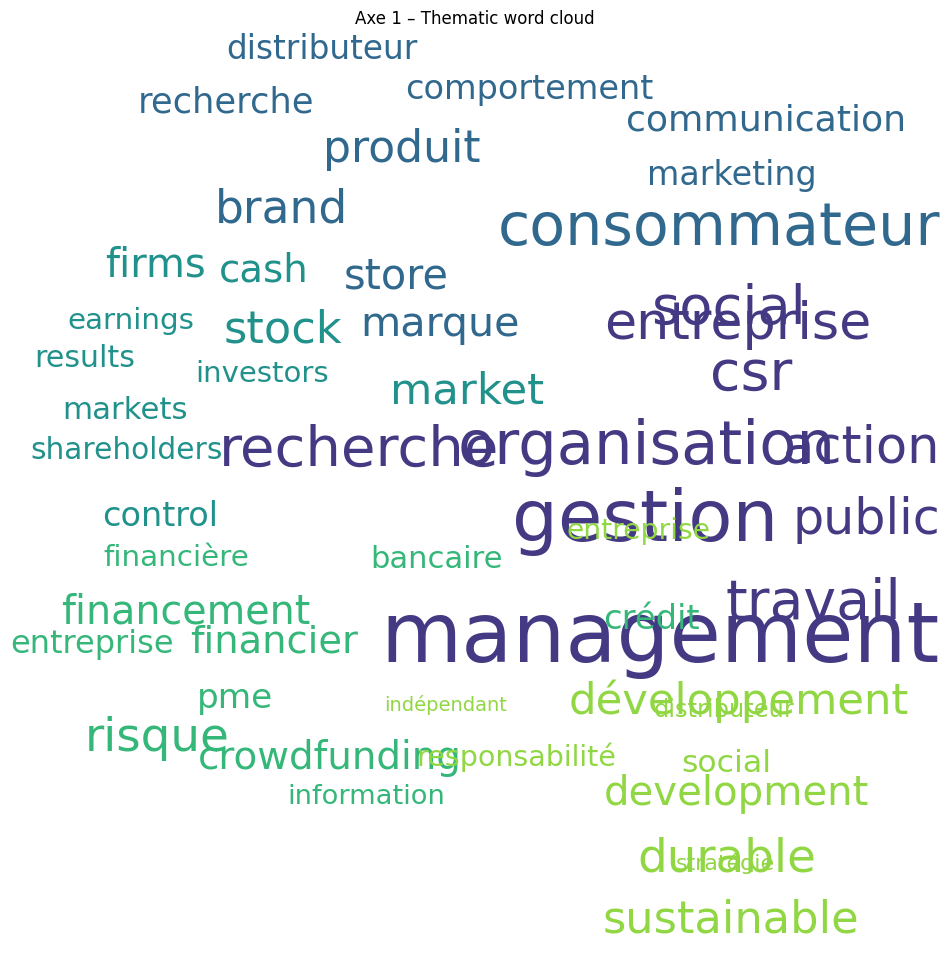

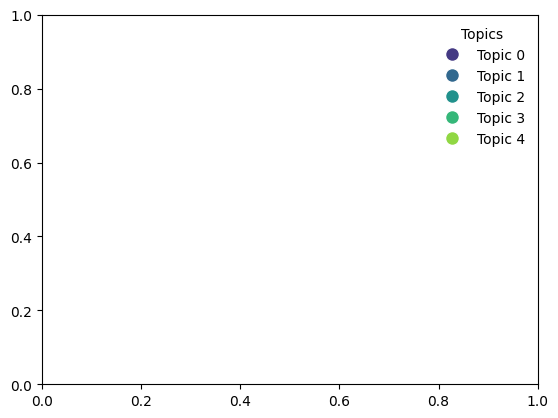

In [80]:
MAX_WORDS_PER_TOPIC = 15

# 收集词
xs, ys, words, sizes, cols = [], [], [], [], []

for topic_id in topic_ids:
    cx, cy = topic_centers[topic_id]
    topic_words = topic_model.get_topic(topic_id)[:MAX_WORDS_PER_TOPIC]
    count = topic_info.loc[topic_info.Topic == topic_id, 'Count'].values[0]

    for word, weight in topic_words:
        r = np.random.uniform(0.1, 0.6)
        theta = np.random.uniform(0, 2*np.pi)
        xs.append(cx + r * np.cos(theta))
        ys.append(cy + r * np.sin(theta))
        words.append(word)
        sizes.append(count * weight)
        cols.append(topic_color[topic_id])

# 缩放字号
sizes_scaled = np.interp(
    np.sqrt(sizes),
    (np.sqrt(min(sizes)), np.sqrt(max(sizes))),
    (14, 60)
)

# 按字号排序（关键）
items = sorted(
    zip(xs, ys, words, sizes_scaled, cols),
    key=lambda x: x[3],
    reverse=True
)

# 绘图
# plt.figure(figsize=(12,12))
# for x, y, word, size, col in items:
#     plt.text(x, y, word, fontsize=size, color=col,
#              ha='center', va='center')

# # layout
# plt.xlim(-2, 2)
# plt.ylim(-2, 2)
# plt.axis('off')
# plt.title(f"Axe {axe_id} – Thematic word cloud")




from adjustText import adjust_text
plt.figure(figsize=(12,12))

texts = []
for x, y, word, size, col in items:
    txt = plt.text(
        x, y, word,
        fontsize=size,
        color=col,
        ha='center',
        va='center'
    )
    texts.append(txt)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axis('off')
plt.title(f"Axe {axe_id} – Thematic word cloud")

adjust_text(
    texts,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    force_text=0.5,
    force_points=0.3
)

plt.show()



# 图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f"Topic {topic_id}",
           markerfacecolor=topic_color[topic_id],
           markersize=10)
    for topic_id in topic_ids
]

plt.legend(handles=legend_elements, title="Topics",
           loc='upper right', frameon=False)

plt.show()


TypeError: 'Text' object is not callable

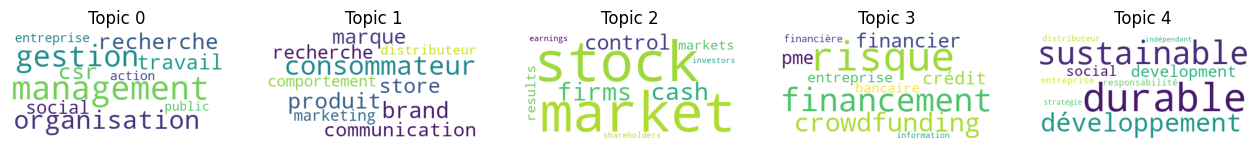

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, len(topic_ids), figsize=(16,4))
for ax, topic_id in zip(axes, topic_ids):
    words = dict(topic_model.get_topic(topic_id))
    wc = WordCloud(background_color="white").generate_from_frequencies(words)
    ax.imshow(wc)
    ax.set_title(f"Topic {topic_id}")
    ax.axis("off")


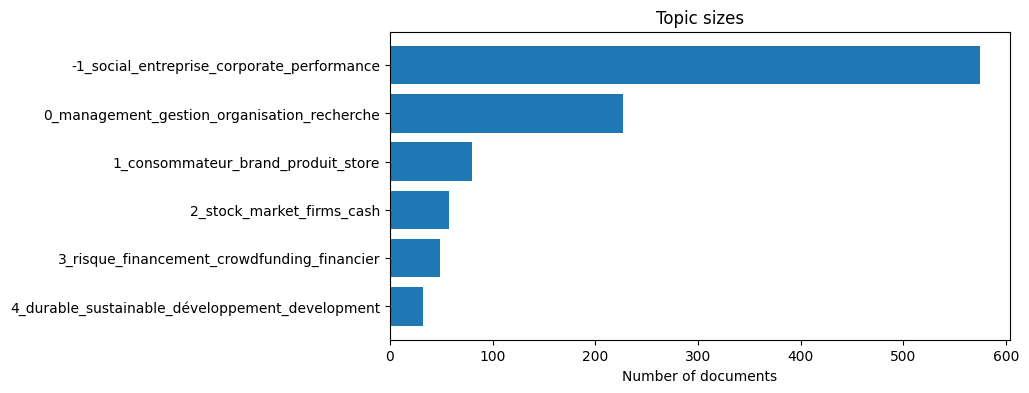

In [18]:
topic_info = topic_model.get_topic_info()

plt.figure(figsize=(8,4))
plt.barh(
    topic_info['Name'],
    topic_info['Count']
)
plt.xlabel("Number of documents")
plt.title("Topic sizes")
plt.gca().invert_yaxis()
plt.show()


In [19]:
topic_model.visualize_barchart(top_n_topics=6, n_words=10)


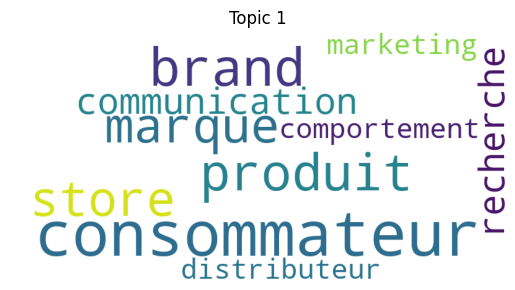

In [20]:
from wordcloud import WordCloud

topic_id = 1
words = dict(topic_model.get_topic(topic_id))

wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(words)

plt.imshow(wc)
plt.axis("off")
plt.title(f"Topic {topic_id}")
plt.show()


In [ ]:
# ✅ 3️⃣ 文档在 topic 空间的 2D 可视化（结构视角）
fig = topic_model.visualize_documents(
    texts,
    topics=topics,
    # embeddings=embeddings
)
fig.show()


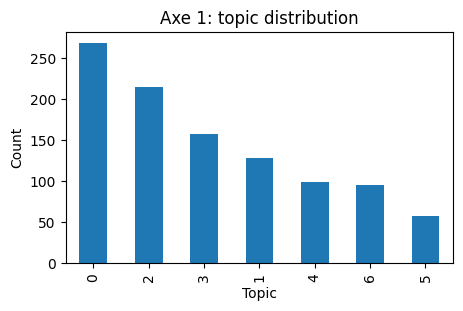

In [29]:
# for axe in sorted(df['axe'].unique()):
sub =df_axe.copy()#= df[df['axe'] == axe]
counts = sub['primary_topic'].value_counts()

plt.figure(figsize=(5,3))
counts.plot(kind='bar')
plt.title(f"Axe {axe_id}: topic distribution")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.show()


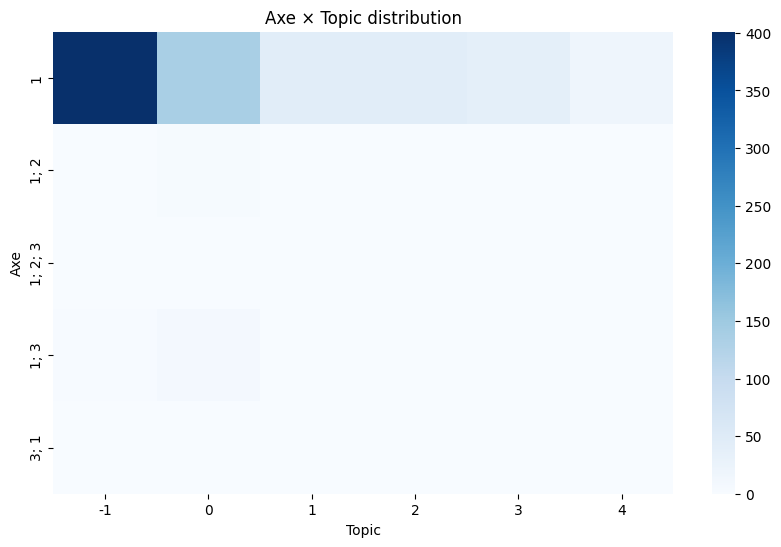

In [24]:
import pandas as pd
import seaborn as sns

df = df_axe.copy()
df['topic'] = topics

pivot = pd.crosstab(df['axe'], df['topic'])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Axe × Topic distribution")
plt.xlabel("Topic")
plt.ylabel("Axe")
plt.show()


### tries:

In [12]:
print(f"{len(set(topics))} topics sous axe{axe_id} : {axe_label.get(axe_id)}")
topic_info = topic_model.get_topic_info()
display(topic_info)

8 topics sous axe1 : Performances et responsabilités


,Topic,Count,Name,Representation,Representative_Docs
0,-1,528,-1_social_corporate_performance_french,"[social, corporate, performance, french, entre...",[rse service public quel articulation cas entr...
1,0,247,0_management_gestion_organisation_social,"[management, gestion, organisation, social, re...",[avant propos gess gestion entreprise social s...
2,1,70,1_consommateur_brand_marque_store,"[consommateur, brand, marque, store, communica...",[falloir concevoir prospectus fonction fidélit...
3,2,60,2_risque_financement_financier_pme,"[risque, financement, financier, pme, entrepri...",[octroi crédit bancaire pme français depuis ré...
4,3,37,3_durable_développement_sustainable_development,"[durable, développement, sustainable, developm...",[distributeur indépendant développement durabl...
5,4,28,4_entrepreneuriat_entrepreneur_femme_quartier,"[entrepreneuriat, entrepreneur, femme, quartie...",[lecture sensible entrepreneuring femme résona...
6,5,27,5_market_stock_emerging_markets,"[market, stock, emerging, markets, bias, equit...",[answer roll critique years later answer roll ...
7,6,23,6_cash_firms_control_shareholders,"[cash, firms, control, shareholders, ownership...",[multiple large shareholders earnings informat...


In [117]:
print(set(topics))
topic_info = topic_model.get_topic_info()
display(topic_info)

{0, 1, -1}


,Topic,Count,Name,Representation,Representative_Docs
0,-1,103,-1_impact_performance_gender_women,"[impact, performance, gender, women, public, i...",[nonprofits user impact evaluation lesson soci...
1,0,637,0_social_management_entreprise_recherche,"[social, management, entreprise, recherche, ge...",[responsabilité social entreprise responsabili...
2,1,280,1_corporate_firms_market_financial,"[corporate, firms, market, financial, stock, c...",[corporate governance voluntary disclosure fir...


In [111]:
print(set(topics))
topic_info = topic_model.get_topic_info()
display(topic_info)

{0, 1, 2, 3, 4, 5, 6, -1}


,Topic,Count,Name,Representation,Representative_Docs
0,-1,528,-1_social_corporate_performance_french,"[social, corporate, performance, french, entre...",[rse service public quel articulation cas entr...
1,0,247,0_management_gestion_organisation_social,"[management, gestion, organisation, social, re...",[avant propos gess gestion entreprise social s...
2,1,70,1_consommateur_brand_marque_store,"[consommateur, brand, marque, store, communica...",[falloir concevoir prospectus fonction fidélit...
3,2,60,2_risque_financement_financier_pme,"[risque, financement, financier, pme, entrepri...",[octroi crédit bancaire pme français depuis ré...
4,3,37,3_durable_développement_sustainable_development,"[durable, développement, sustainable, developm...",[distributeur indépendant développement durabl...
5,4,28,4_entrepreneuriat_entrepreneur_femme_quartier,"[entrepreneuriat, entrepreneur, femme, quartie...",[lecture sensible entrepreneuring femme résona...
6,5,27,5_market_stock_emerging_markets,"[market, stock, emerging, markets, bias, equit...",[answer roll critique years later answer roll ...
7,6,23,6_cash_firms_control_shareholders,"[cash, firms, control, shareholders, ownership...",[multiple large shareholders earnings informat...


In [15]:
# df_axe['top_topic'] = topics  # 把 topic ID 赋回 dataframe
import numpy as np

# 唯一 topic（最大概率对应）
df_axe['primary_topic'] = np.argmax(probs, axis=1)

# 多 topic（概率超过阈值）
thresh = 0.2
df_axe['multi_topics'] = [
    list(np.where(probs[i] > thresh)[0]) for i in range(len(df_axe))
]

# 查看 topic 0 的文章
display(df_axe[['title_s','abstract_s','keyword_s','primary_topic',"multi_topics"]].head())


,title_s,abstract_s,keyword_s,primary_topic,multi_topics
51,Entre logique et attitudes : une approche sémi...,,Pragmatisme; Signes; Outils de gestion,0,[0]
58,Le consumérisme digital au service des transit...,Nous proposons dans cette communication une ét...,Labellisation socio-environnementale; Consomma...,3,"[1, 3]"
68,Women directors on traditionally male-dominate...,Stock exchanges are regulated markets that pro...,Stock exchanges; Corporate governance; Financi...,6,[]
74,De la RSE à la Responsabilité Territoriale des...,"En Polynésie française, la Responsabilité Soci...",RSE responsabilité territoriale Polynésie fr...,0,[0]
94,Critiques anciennes et renouvelées de la produ...,Ce chapitre vise d’abord à synthétiser les cri...,Productivité; Sureffectif; Travail; Effectif; ...,0,[0]


## try2

In [ ]:
# df=df_predicted.copy()

# def parse_axes(x):
#     if pd.isna(x):
#         return []
#     return [a.strip() for a in str(x).split(';')]
# df=df_predicted.copy()
# df['axe_list'] = df['final_axe'].apply(parse_axes)


# #Step 2：合并三种 embedding（稳健版本）
# def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
#     vecs = []
#     weights = []

#     if isinstance(row['emb_title_s'], np.ndarray):
#         vecs.append(row['emb_title_s'])
#         weights.append(w_title)

#     if isinstance(row['emb_keyword_s'], np.ndarray):
#         vecs.append(row['emb_keyword_s'])
#         weights.append(w_kw)

#     if isinstance(row['emb_abstract_s'], np.ndarray):
#         vecs.append(row['emb_abstract_s'])
#         weights.append(w_abs)

#     if not vecs:
#         return None

#     return np.average(vecs, axis=0, weights=weights)
# df['combined_emb'] = df.apply(combine_embeddings, axis=1)


# print(df['combined_emb'].shape)  # shape = (n_articles, emb_dim)
# print(df['axe_list'])    # e.g. ['1'], ['1','3']

# X = np.vstack(df['combined_emb'].dropna().values)
# df_plot = df.loc[df['combined_emb'].notna()].copy()


d:\miniconda3\envs\irg_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


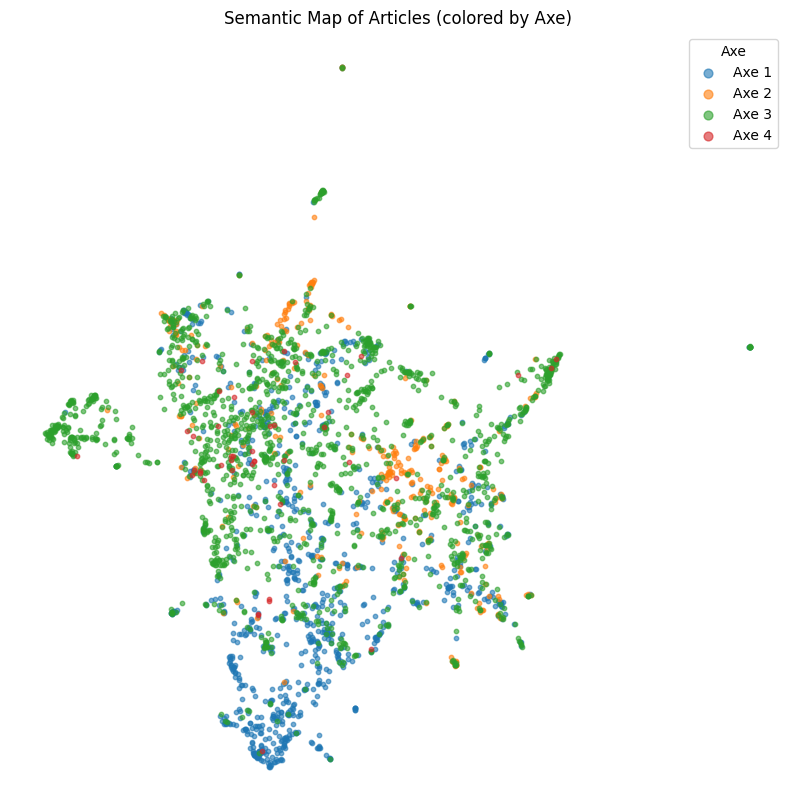

In [16]:
import umap

df_plot=df_plot_exploded.copy()
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_2d = reducer.fit_transform(X)
df_plot['x'] = X_2d[:, 0]
df_plot['y'] = X_2d[:, 1]


# def main_axe(axes):
#     return axes[0] if axes else None

# df_plot['main_axe'] = df_plot['axe_list'].apply(main_axe)

plt.figure(figsize=(10, 10))

for axe, g in df_plot.groupby('final_axe'):
    plt.scatter(
        g['x'], g['y'],
        s=10,
        alpha=0.6,
        label=f"Axe {axe}"
    )

plt.legend(title="Axe", markerscale=2)
plt.title("Semantic Map of Articles (colored by Axe)")
plt.axis('off')
plt.show()


In [ ]:
for axe, emb in axe_embeddings.items():
    center = reducer.transform(emb.reshape(1, -1))
    plt.scatter(center[0,0], center[0,1],
                s=300, marker='X', edgecolor='black')
    plt.text(center[0,0], center[0,1], f"Axe {axe}",
             fontsize=12, weight='bold')




## TRY1

In [ ]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]
df=df_predicted.copy()
df['axe_list'] = df['final_axe'].apply(parse_axes)


#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)



#Step 3：按 axe 聚合语义向量（关键）
axe_embeddings = {}
all_axes = sorted({a for axes in df['axe_list'] for a in axes})

for axe in all_axes:
    idx = df['axe_list'].apply(lambda x: axe in x)
    emb_list = df.loc[idx, 'combined_emb'].dropna().tolist()

    if emb_list:
        axe_embeddings[axe] = np.vstack(emb_list).mean(axis=0)


# Step 4：计算 axe–axe 语义相似度
axes = list(axe_embeddings.keys())
E = np.vstack([axe_embeddings[a] for a in axes])

S = cosine_similarity(E)
pd.DataFrame(S, index=axes, columns=axes)


,1,2,3,4
1,1.000000,0.970100,0.980873,0.950529
2,0.970100,1.000000,0.981196,0.950960
3,0.980873,0.981196,1.000000,0.966930
4,0.950529,0.950960,0.966930,1.000000


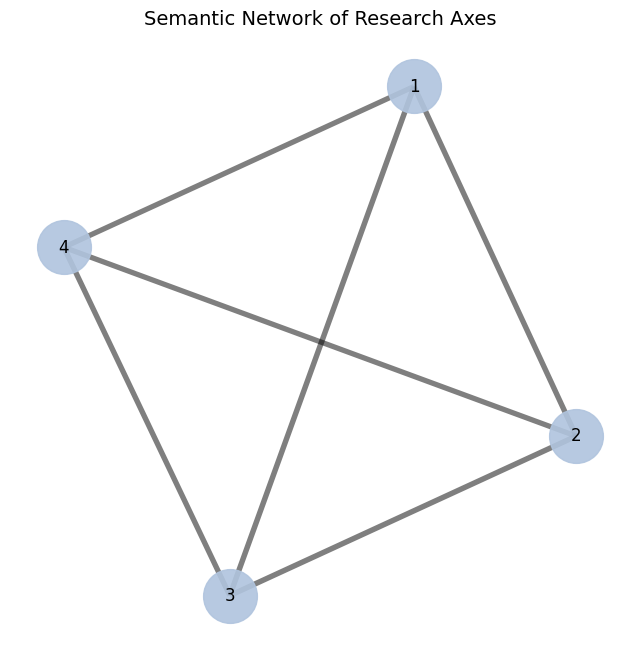

In [12]:
# Step 5：构建语义网络
G = nx.Graph()

for axe in axes:
    G.add_node(axe)

threshold = 0.3
for i, a1 in enumerate(axes):
    for j, a2 in enumerate(axes):
        if i < j and S[i, j] >= threshold:
            G.add_edge(a1, a2, weight=S[i, j])



# Step 6：力导向布局 + 可视化
pos = nx.spring_layout(G, weight='weight', seed=42)
plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(
    G, pos,
    node_size=1500,
    node_color='lightsteelblue',
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight'] * 4 for u, v in G.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(
    G, pos,
    font_size=12
)

plt.title("Semantic Network of Research Axes", fontsize=14)
plt.axis('off')
plt.show()


In [4]:
from utils.preprocess import explode_by_col
df_split=explode_by_col(df_predicted, col='final_axe')
print(len(df_predicted), len(df_split))
print(df_split.final_axe.value_counts(dropna=False))
print(df_split.language_s.value_counts(dropna=False))
# print(df_split.final_axe.dtype)
# display(df_split.head())

2734 3036
final_axe
3    1596
1    1020
2     373
4      47
Name: count, dtype: int64
language_s
fr    1834
en    1190
pt       5
es       4
ru       1
it       1
pl       1
Name: count, dtype: int64


## tfidf:

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
import json

path_stopwords='../external_data\stopwords_nltk.json'
with open(path_stopwords,'r', encoding='utf-8')as f:
    stopwords=json.load(f)

df_split["all_text"] = (
    df_split[["title_s", "keyword_s", "abstract_s"]]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.strip()
)
display(df_split[['title_s','keyword_s','abstract_s','all_text']].head())

df_split_notna=df_split[df_split['all_text'].notna()]



print(len(df_split),len(df_split_notna))
print(df_split_notna.final_axe.value_counts(dropna=False))

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=stopwords,  # 或自定义
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(df_split_notna["all_text"])
print(X_tfidf.shape)

feature_names = np.array(vectorizer.get_feature_names_out())

,title_s,keyword_s,abstract_s,all_text
0,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,Entrepreneuriat de nécessité (versus opportuni...
0,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,Entrepreneuriat de nécessité (versus opportuni...
1,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,Responsible entrepreneurship: From motivations...
1,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,Responsible entrepreneurship: From motivations...
2,Agencer des safe spaces en marketing des servi...,Marketing des services; Sécurité; Transformati...,NaN,Agencer des safe spaces en marketing des servi...


3039 3039
final_axe
3      1546
1       994
2       405
4        85
nan       9
Name: count, dtype: int64
(3039, 3000)


In [62]:
# def top_terms_for_axe(axe_label, top_k=15):
#     idx = df_split_abstract["final_axe"] == axe_label
#     tfidf_mean = X_tfidf[idx].mean(axis=0)
#     top_idx = np.argsort(tfidf_mean.A1)[::-1][:top_k]
#     return feature_names[top_idx]

def top_terms_for_axe(axe_label, top_k=15):
    idx = (df_split_notna["final_axe"] == axe_label).values
    tfidf_mean = X_tfidf[idx].mean(axis=0)
    top_idx = np.argsort(tfidf_mean.A1)[::-1][:top_k]
    return feature_names[top_idx]

dict_axes={
    "1": "Performances et responsabilités",
    "2": "Société de services et services à la société",
    "3": "Innovations, transformations et résistances organisationnelles et sociétales",
    "4": "Ouvrages pédagogiques"
}


for axe in ["1","2","3","4"]:
    kw=top_terms_for_axe(axe_label=axe, top_k=15)
    print(f"AXE {dict_axes.get(axe,None)}: \n{kw}\n")
    


AXE Performances et responsabilités: 
['management' 'performance' 'entreprises' 'corporate' 'gestion' 'social'
 'capital' 'rse' 'entreprise' 'financial' 'france' 'market' 'sociale'
 'french' 'firms']

AXE Société de services et services à la société: 
['service' 'marketing' 'client' 'services' 'customer' 'management'
 'relation' 'participation' 'travail' 'clients' 'recherche' 'santé'
 'research' 'confiance' 'place']

AXE Innovations, transformations et résistances organisationnelles et sociétales: 
['management' 'innovation' 'recherche' 'gestion' 'luxe' 'ludopédagogie'
 'travail' 'marketing' 'research' 'changement' 'pratiques' 'france'
 'parfumerie' 'organisations' 'organizational']

AXE Ouvrages pédagogiques: 
['recherche' 'management' 'cas' 'gestion' 'ouvrage' 'marketing'
 'ressources' 'collecte' 'finance' 'cet ouvrage' 'grh' 'formation'
 'chapitre' 'action' 'cet']



In [64]:
from itertools import combinations
from collections import Counter
nodes = top_terms_for_axe("1", top_k=30)

edges = Counter()
for text in df_split_notna[df_split_notna["final_axe"]=="1"]["all_text"]:
    words = set(text.split()) & set(nodes)
    for pair in combinations(words, 2):
        edges[pair] += 1
edges

Counter({('recherche', 'article'): 23,
         ('recherche', 'sociale'): 6,
         ('article', 'sociale'): 12,
         ('développement', 'durable'): 31,
         ('développement', 'article'): 16,
         ('développement', 'corporate'): 4,
         ('développement', 'sociale'): 15,
         ('développement', 'performance'): 5,
         ('durable', 'article'): 9,
         ('durable', 'corporate'): 3,
         ('durable', 'sociale'): 11,
         ('durable', 'performance'): 4,
         ('article', 'corporate'): 6,
         ('article', 'performance'): 14,
         ('corporate', 'sociale'): 2,
         ('corporate', 'performance'): 19,
         ('sociale', 'performance'): 8,
         ('social', 'développement'): 10,
         ('social', 'durable'): 8,
         ('social', 'sociale'): 27,
         ('social', 'recherche'): 15,
         ('développement', 'recherche'): 23,
         ('durable', 'recherche'): 10,
         ('sociale', 'recherche'): 8,
         ('sociale', 'innovation'): 1,
    

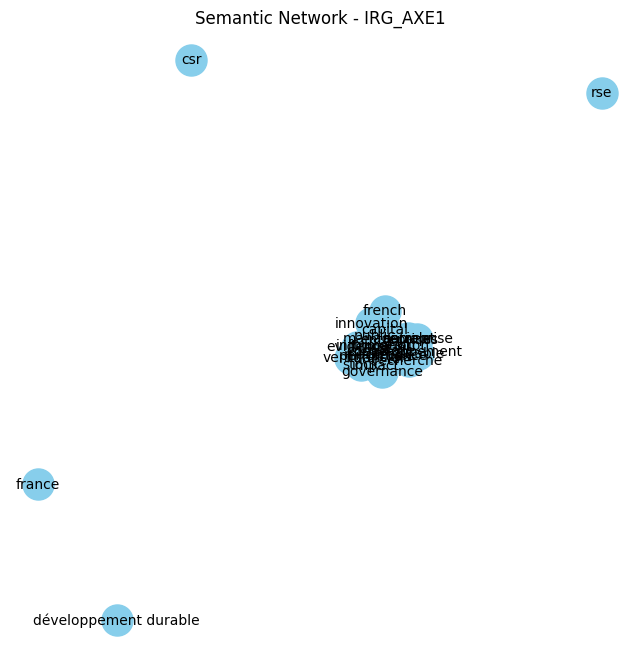

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(nodes)
for (w1, w2), weight in edges.items():
    G.add_edge(w1, w2, weight=weight)

plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, k=0.3)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=[d['weight']*0.2 for (u,v,d) in G.edges(data=True)])
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Réseau sémantique")
plt.axis("off")
plt.show()


## clustering within axe:

In [ ]:
from sklearn.cluster import KMeans

def cluster_within_axe(axe_label, k=2):
    idx = df["final_axe"] == axe_label
    X = np.stack(df.loc[idx, "emb_abstract_s"])
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    return labels
